# Training history comparison: datasets A and B (fixed N = 8)

A direct comparison of the PPO logs in `A_seed0_Nfixed8` and `B_seed0_Nfixed8`, following the concise approach of notebook 03. This notebook reports logged training metrics only; it does not run inference or new rollouts.

## Load the training logs

Load the four logged arrays directly. No row filtering or data reshaping is needed for these plots and summary statistics.

In [1]:
from pathlib import Path

import numpy as np

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if not (project_root / "src").exists():
    raise FileNotFoundError("Could not find the src folder from the current working directory.")

log_paths = {
    "Dataset A": project_root / "results" / "A_seed0_Nfixed8" / "train_log.npz",
    "Dataset B": project_root / "results" / "B_seed0_Nfixed8" / "train_log.npz",
}

histories = {}
for name, path in log_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing training log: {path}")
    with np.load(path) as data:
        histories[name] = {key: data[key] for key in data.files}

print(f"Project root: {project_root}")
print("Loaded:", ", ".join(histories))

Project root: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds
Loaded: Dataset A, Dataset B


## Summary statistics and comparison

The table shows the first, final, and best logged values, plus the first-to-final change. Success-rate statistics ignore `NaN` entries, which occur when no episodes finish in an update.

In [2]:
import pandas as pd

summary_rows = []
for dataset, history in histories.items():
    success = history["success_rate"]
    success = success[np.isfinite(success)]
    summary_rows.append({
        "dataset": dataset,
        "updates": len(history["timesteps"]),
        "final_timesteps": int(history["timesteps"][-1]),
        "reward_first": history["reward"][0],
        "reward_final": history["reward"][-1],
        "reward_best": history["reward"].max(),
        "margin_first": history["margin"][0],
        "margin_final": history["margin"][-1],
        "margin_best": history["margin"].max(),
        "success_first": success[0] if len(success) else np.nan,
        "success_final": success[-1] if len(success) else np.nan,
        "success_best": success.max() if len(success) else np.nan,
    })

summary = pd.DataFrame(summary_rows).set_index("dataset")
display(summary.style.format({
    "reward_first": "{:+.3f}", "reward_final": "{:+.3f}", "reward_best": "{:+.3f}",
    "margin_first": "{:+.3f}", "margin_final": "{:+.3f}", "margin_best": "{:+.3f}",
    "success_first": "{:.1%}", "success_final": "{:.1%}", "success_best": "{:.1%}",
}, na_rep="—"))

for dataset, history in histories.items():
    success = history["success_rate"]
    success = success[np.isfinite(success)]
    if len(success):
        print(
            f"{dataset}: reward {history['reward'][0]:+.3f} -> {history['reward'][-1]:+.3f}; "
            f"margin {history['margin'][0]:+.3f} -> {history['margin'][-1]:+.3f}; "
            f"success rate {success[0]:.1%} -> {success[-1]:.1%}."
        )
    else:
        print(f"{dataset}: no finite success-rate values were logged.")

same_horizon = (
    summary["final_timesteps"].nunique() == 1 and summary["updates"].nunique() == 1
)
print(f"Same logged horizon and update count: {same_horizon}")

,updates,final_timesteps,reward_first,reward_final,reward_best,margin_first,margin_final,margin_best,success_first,success_final,success_best
dataset,,,,,,,,,,,
Dataset A,1953,1999872,-1.000,-1.000,-1.000,-5.766,-7.998,-5.374,0.0%,0.0%,0.0%
Dataset B,1953,1999872,-0.965,-0.990,-0.946,-3.173,-5.228,-2.794,0.0%,2.8%,14.6%


Dataset A: reward -1.000 -> -1.000; margin -5.766 -> -7.998; success rate 0.0% -> 0.0%.
Dataset B: reward -0.965 -> -0.990; margin -3.173 -> -5.228; success rate 0.0% -> 2.8%.
Same logged horizon and update count: True


## Training curves and mean-margin note

Curves are shown as logged, without smoothing. The margin calculation below reports the share of updates whose batch-mean margin is positive.

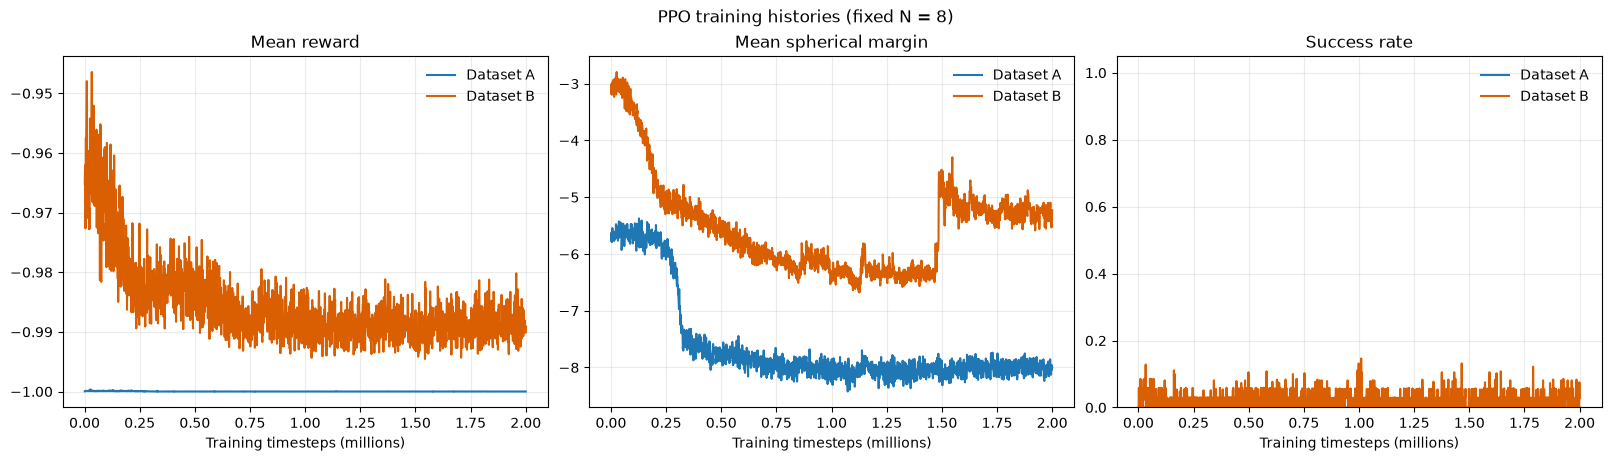

Dataset A: 0.0% of updates have a positive mean margin; overall mean = -7.627.
Dataset B: 0.0% of updates have a positive mean margin; overall mean = -5.519.
This is the fraction of updates with a positive batch-mean margin, not the fraction of individual states with positive margin. A few large positive values can outweigh many smaller negative values.


In [3]:
import matplotlib.pyplot as plt

colors = {"Dataset A": "#1f77b4", "Dataset B": "#d95f02"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for dataset, history in histories.items():
    x = history["timesteps"] / 1_000_000
    color = colors[dataset]
    axes[0].plot(x, history["reward"], label=dataset, color=color, linewidth=1.5)
    axes[1].plot(x, history["margin"], label=dataset, color=color, linewidth=1.5)
    axes[2].plot(x, history["success_rate"], label=dataset, color=color, linewidth=1.5)

for ax in axes:
    ax.set_xlabel("Training timesteps (millions)")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

axes[0].set_title("Mean reward")
axes[1].set_title("Mean spherical margin")
axes[2].set_title("Success rate")
axes[2].set_ylim(0, 1.05)
fig.suptitle("PPO training histories (fixed N = 8)")
plt.show()

for dataset, history in histories.items():
    margin = history["margin"]
    positive_fraction = np.mean(margin > 0)
    print(f"{dataset}: {positive_fraction:.1%} of updates have a positive mean margin; "
          f"overall mean = {margin.mean():+.3f}.")

print("This is the fraction of updates with a positive batch-mean margin, "
      "not the fraction of individual states with positive margin. A few large "
      "positive values can outweigh many smaller negative values.")